In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import os
os.environ['R_HOME'] = 'D:/Program Files/R-4.5.0' #@TODO include in some setup file

from simulation_engine.scenarios.iv.binary_iv import BinaryIV
from simulation_engine.scenarios.conf.binary_conf import BinaryConf
from simulation_engine.scenarios.iv.continuous_iv import ContinuousIV
from simulation_engine.util.plotting_util import PlottingUtil

import pandas as pd
pd.set_option('display.max_columns', None)

#disable warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns
import math
# from linearmodels.iv import IV2SLS
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.neural_network import MLPClassifier
# Train a decision tree classifier to predict 'tightest_bounds'
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from simulation_engine.util.plotting_util import PlottingUtil
pd.options.mode.chained_assignment = None  # default='warn'
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import numpy as np




In [3]:
data = []

for i in range(10):
    sim = BinaryConf._generate_data(n=500, b_U_X=1, b_U_Y=-1, b_X_Y=2, intercept_X=0.3, intercept_Y=-0.5, p_U=0.8, squasher_X_name='sigmoid', squasher_Y_name='sigmoid')
    data.append(sim)

df = pd.DataFrame(data)
scenario = BinaryConf(df)
scenario.run()
results_variance = scenario.data


Running ATE_OLS-0.99...
ATE_OLS-0.99 completed in 0.09 seconds.
Running ATE_OLS-0.98...
ATE_OLS-0.98 completed in 0.04 seconds.
Running ATE_OLS-0.95...
ATE_OLS-0.95 completed in 0.03 seconds.
Running ATE_causaloptim...
ATE_causaloptim completed in 6.64 seconds.
Running PNS_causaloptim...
PNS_causaloptim completed in 5.20 seconds.
Running ATE_autobound...
ATE_autobound completed in 2.22 seconds.
Running PNS_autobound...
PNS_autobound completed in 0.80 seconds.
Running ATE_entropybounds-0.80...
ATE_entropybounds-0.80 completed in 0.60 seconds.
Running ATE_entropybounds-0.20...
ATE_entropybounds-0.20 completed in 0.61 seconds.
Running ATE_entropybounds-0.10...
ATE_entropybounds-0.10 completed in 0.59 seconds.
Running PNS_entropybounds-0.80...
PNS_entropybounds-0.80 completed in 0.31 seconds.
Running PNS_entropybounds-0.20...
PNS_entropybounds-0.20 completed in 0.48 seconds.
Running PNS_entropybounds-0.10...
PNS_entropybounds-0.10 completed in 0.38 seconds.
Running PNS_entropybounds-trueTh

d:\TUM Workspace\Thesis Workspace\causal-bounds\binConf\..\simulation_engine\algorithms\zaffalonbounds.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[results_df.columns] = results_df
d:\TUM Workspace\Thesis Workspace\causal-bounds\binConf\..\simulation_engine\algorithms\zaffalonbounds.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[results_df.columns] = results_df
d:\TUM Workspace\Thesis Workspace\causal-bounds\binConf\..\simulation_engine\algorithms\zaffalonbounds.py:30: PerformanceWarning: DataFrame is hig

ATE_zaffalonbounds completed in 43.97 seconds.
Running PNS_zaffalonbounds...
PNS_zaffalonbounds completed in 32.54 seconds.
Running ATE_tianpearl...
ATE_tianpearl completed in 0.02 seconds.
Running PNS_tianpearl...
PNS_tianpearl completed in 0.01 seconds.
Running ATE_manski...
ATE_manski completed in 0.02 seconds.
Total runtime: 96.29 seconds.


d:\TUM Workspace\Thesis Workspace\causal-bounds\binConf\..\simulation_engine\algorithms\zaffalonbounds.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[results_df.columns] = results_df
d:\TUM Workspace\Thesis Workspace\causal-bounds\binConf\..\simulation_engine\algorithms\zaffalonbounds.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[results_df.columns] = results_df
d:\TUM Workspace\Thesis Workspace\causal-bounds\binConf\..\simulation_engine\algorithms\zaffalonbounds.py:30: PerformanceWarning: DataFrame is hig

In [7]:
results_variance

,seed,intercept_X,intercept_Y,b_U_X,b_X_Y,b_U_Y,ATE_true,PNS_true,p_Y1_mean,p_Y0_mean,p_U,U,X,Y,epsilon_X,sigma_X_vec,epsilon_Y,sigma_Y_vec,entropy_U,entropy_X,entropy_Y,squasher_X_name,squasher_Y_name,heteroskedasticity_structure,ATE_OLS-0.99_bound_lower,ATE_OLS-0.99_bound_upper,ATE_OLS-0.99_bound_valid,ATE_OLS-0.99_bound_width,ATE_OLS-0.99_bound_failed,ATE_OLS-0.98_bound_lower,ATE_OLS-0.98_bound_upper,ATE_OLS-0.98_bound_valid,ATE_OLS-0.98_bound_width,ATE_OLS-0.98_bound_failed,ATE_OLS-0.95_bound_lower,ATE_OLS-0.95_bound_upper,ATE_OLS-0.95_bound_valid,ATE_OLS-0.95_bound_width,ATE_OLS-0.95_bound_failed,ATE_causaloptim_bound_lower,ATE_causaloptim_bound_upper,ATE_causaloptim_bound_valid,ATE_causaloptim_bound_width,ATE_causaloptim_bound_failed,PNS_causaloptim_bound_lower,PNS_causaloptim_bound_upper,PNS_causaloptim_bound_valid,PNS_causaloptim_bound_width,PNS_causaloptim_bound_failed,ATE_autobound_bound_lower,ATE_autobound_bound_upper,ATE_autobound_bound_valid,ATE_autobound_bound_width,ATE_autobound_bound_failed,PNS_autobound_bound_lower,PNS_autobound_bound_upper,PNS_autobound_bound_valid,PNS_autobound_bound_width,PNS_autobound_bound_failed,ATE_entropybounds-0.80_bound_lower,ATE_entropybounds-0.80_bound_upper,ATE_entropybounds-0.80_bound_valid,ATE_entropybounds-0.80_bound_width,ATE_entropybounds-0.80_bound_failed,ATE_entropybounds-0.80_theta,ATE_entropybounds-0.20_bound_lower,ATE_entropybounds-0.20_bound_upper,ATE_entropybounds-0.20_bound_valid,ATE_entropybounds-0.20_bound_width,ATE_entropybounds-0.20_bound_failed,ATE_entropybounds-0.20_theta,ATE_entropybounds-0.10_bound_lower,ATE_entropybounds-0.10_bound_upper,ATE_entropybounds-0.10_bound_valid,ATE_entropybounds-0.10_bound_width,ATE_entropybounds-0.10_bound_failed,ATE_entropybounds-0.10_theta,PNS_entropybounds-0.80_bound_lower,PNS_entropybounds-0.80_bound_upper,PNS_entropybounds-0.80_bound_valid,PNS_entropybounds-0.80_bound_width,PNS_entropybounds-0.80_bound_failed,PNS_entropybounds-0.80_theta,PNS_entropybounds-0.20_bound_lower,PNS_entropybounds-0.20_bound_upper,PNS_entropybounds-0.20_bound_valid,PNS_entropybounds-0.20_bound_width,PNS_entropybounds-0.20_bound_failed,PNS_entropybounds-0.20_theta,PNS_entropybounds-0.10_bound_lower,PNS_entropybounds-0.10_bound_upper,PNS_entropybounds-0.10_bound_valid,PNS_entropybounds-0.10_bound_width,PNS_entropybounds-0.10_bound_failed,PNS_entropybounds-0.10_theta,PNS_entropybounds-trueTheta_bound_lower,PNS_entropybounds-trueTheta_bound_upper,PNS_entropybounds-trueTheta_bound_valid,PNS_entropybounds-trueTheta_bound_width,PNS_entropybounds-trueTheta_bound_failed,PNS_entropybounds-trueTheta_theta,ATE_entropybounds-trueTheta_bound_lower,ATE_entropybounds-trueTheta_bound_upper,ATE_entropybounds-trueTheta_bound_valid,ATE_entropybounds-trueTheta_bound_width,ATE_entropybounds-trueTheta_bound_failed,ATE_entropybounds-trueTheta_theta,PNS_entropybounds-randomTheta_bound_lower,PNS_entropybounds-randomTheta_bound_upper,PNS_entropybounds-randomTheta_bound_valid,PNS_entropybounds-randomTheta_bound_width,PNS_entropybounds-randomTheta_bound_failed,PNS_entropybounds-randomTheta_theta,ATE_entropybounds-randomTheta_bound_lower,ATE_entropybounds-randomTheta_bound_upper,ATE_entropybounds-randomTheta_bound_valid,ATE_entropybounds-randomTheta_bound_width,ATE_entropybounds-randomTheta_bound_failed,ATE_entropybounds-randomTheta_theta,ATE_zaffalonbounds_bound_lower,ATE_zaffalonbounds_bound_upper,ATE_zaffalonbounds_bound_valid,ATE_zaffalonbounds_bound_width,ATE_zaffalonbounds_bound_failed,PNS_zaffalonbounds_bound_lower,PNS_zaffalonbounds_bound_upper,PNS_zaffalonbounds_bound_valid,PNS_zaffalonbounds_bound_width,PNS_zaffalonbounds_bound_failed,ATE_tianpearl_bound_lower,ATE_tianpearl_bound_upper,ATE_tianpearl_bound_width,ATE_tianpearl_bound_failed,ATE_tianpearl_bound_valid,PNS_tianpearl_bound_lower,PNS_tianpearl_bound_upper,PNS_tianpearl_bound_width,PNS_tianpearl_bound_failed,PNS_tianpearl_bound_valid,ATE_manski_bound_lower,ATE_manski_bound_upper,ATE_manski_bound_width,ATE_manski

In [ ]:
#generated like this:
# BinaryConf._generate_data(n=500, b_U_X=1, b_U_Y=-1, b_X_Y=2, intercept_X=0.3, intercept_Y=-0.5, p_U=0.6, squasher_X_name='sigmoid', squasher_Y_name='sigmoid')
results_variance = pd.read_pickle('varianceCheck/results_variance.pkl')
scenario = BinaryConf(results_variance)

results_variance.columns.to_list()

['seed',
 'intercept_X',
 'intercept_Y',
 'b_U_X',
 'b_X_Y',
 'b_U_Y',
 'ATE_true',
 'PNS_true',
 'p_Y1_mean',
 'p_Y0_mean',
 'p_U',
 'U',
 'X',
 'Y',
 'epsilon_X',
 'sigma_X_vec',
 'epsilon_Y',
 'sigma_Y_vec',
 'entropy_U',
 'entropy_X',
 'entropy_Y',
 'squasher_X_name',
 'squasher_Y_name',
 'heteroskedasticity_structure',
 'ATE_OLS-0.99_bound_lower',
 'ATE_OLS-0.99_bound_upper',
 'ATE_OLS-0.99_bound_valid',
 'ATE_OLS-0.99_bound_width',
 'ATE_OLS-0.99_bound_failed',
 'ATE_OLS-0.98_bound_lower',
 'ATE_OLS-0.98_bound_upper',
 'ATE_OLS-0.98_bound_valid',
 'ATE_OLS-0.98_bound_width',
 'ATE_OLS-0.98_bound_failed',
 'ATE_OLS-0.95_bound_lower',
 'ATE_OLS-0.95_bound_upper',
 'ATE_OLS-0.95_bound_valid',
 'ATE_OLS-0.95_bound_width',
 'ATE_OLS-0.95_bound_failed',
 'ATE_causaloptim_bound_lower',
 'ATE_causaloptim_bound_upper',
 'ATE_causaloptim_bound_valid',
 'ATE_causaloptim_bound_width',
 'ATE_causaloptim_bound_failed',
 'PNS_causaloptim_bound_lower',
 'PNS_causaloptim_bound_upper',
 'PNS_causa

In [ ]:
# expect dataset named results_variance
#loop through each algorithm (given variables ATE_Algs, PNS_Algs and Algs)
## measure the mean and std deviation of {algname}_bound_width.
## measure how many % of the executions failed: {algname}_bound_failed (boolean)
## mease how many % of the exections were valid: {algname}_bound_valid (boolean)
## measure the avg. invalid distance: of those that were invalid, how far was the upper/lowerbound from the {query}_true for query in {ATE, PNS}
# print all theses statics in a table, each algorithm in a row, each statistic in a column

ATE_Algs = scenario.get_algorithms('ATE')
PNS_Algs = scenario.get_algorithms('PNS')
# concatenate the two lists
Algs = ATE_Algs + PNS_Algs

#@TODO: Display mean/std of upper and lower bound?

# Initialize a dictionary to hold the statistics
stats = {
    'Algorithm': [],
    'Mean Bound Width': [],
    'Std Dev Bound Width': [],
    'Percentage Failed': [],
    'Percentage Valid': [],
    # 'Avg Invalid Distance Upper Bound': [],
    # 'Avg Invalid Distance Lower Bound': []
}
# Loop through each algorithm
for alg in Algs:
    #calulate statistics
    mean_bound_width = results_variance[f'{alg}_bound_width'].mean()
    std_bound_width = results_variance[f'{alg}_bound_width'].std()
    percentage_failed = results_variance[f'{alg}_bound_failed'].mean() * 100
    percentage_valid = results_variance[f'{alg}_bound_valid'].mean() * 100

    # extract query: cols are of the form {query}_{alg}_...
    query = alg.split('_')[0]  # Extract the query part from the algorithm name
    # avg_invalid_distance_upper = results_variance[results_variance[f'{alg}_bound_valid'] == False][f'{alg}_bound_upper'].mean() - results_variance[f'{query}_true'].mean()
    # avg_invalid_distance_lower = results_variance[results_variance[f'{alg}_bound_valid'] == False][f'{alg}_bound_lower'].mean() - results_variance[f'{query}_true'].mean()
    # Append the statistics to the dictionary
    stats['Algorithm'].append(alg)
    stats['Mean Bound Width'].append(mean_bound_width)
    stats['Std Dev Bound Width'].append(std_bound_width)
    stats['Percentage Failed'].append(percentage_failed)
    stats['Percentage Valid'].append(percentage_valid)
    # stats['Avg Invalid Distance Upper Bound'].append(avg_invalid_distance_upper)
    # stats['Avg Invalid Distance Lower Bound'].append(avg_invalid_distance_lower)
# Create a DataFrame from the statistics dictionary
stats_df = pd.DataFrame(stats)
# Display the DataFrame
stats_df

,Algorithm,Mean Bound Width,Std Dev Bound Width,Percentage Failed,Percentage Valid
0,ATE_OLS-0.99,0.234430,0.007223,0.0,10.0
1,ATE_OLS-0.98,0.211725,0.006524,0.0,10.0
2,ATE_OLS-0.95,0.178379,0.005496,0.0,10.0
3,ATE_causaloptim,1.000000,0.000000,0.0,100.0
4,ATE_autobound,1.000000,0.000000,0.0,100.0
5,ATE_entropybounds-0.80,0.999998,0.000006,0.0,10.0
6,ATE_entropybounds-0.20,0.917422,0.009982,0.0,10.0
7,ATE_entropybounds-0.10,0.730641,0.012199,0.0,10.0
8,ATE_entropybounds-trueTheta,0.999996,0.000011,0.0,10.0
9,ATE_entropybounds-randomTheta,0.825073,0.244169,0.0,10.0


count    2000.000000
mean        0.675859
std         0.021264
min         0.612000
25%         0.662000
50%         0.676000
75%         0.690000
max         0.734000
Name: PNS_tianpearl_bound_width, dtype: float64

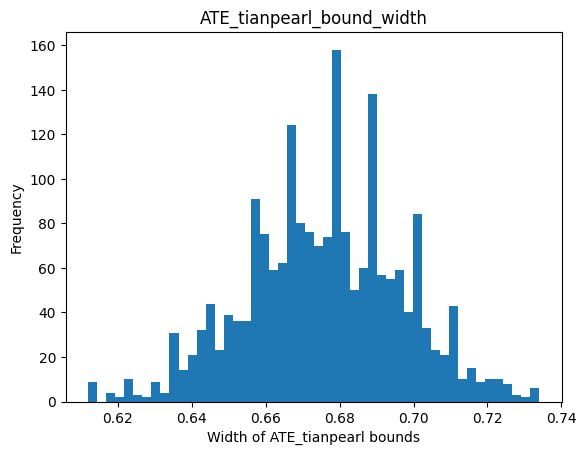

In [ ]:
results_variance['PNS_tianpearl_bound_width'].plot(kind='hist', bins=50, title='ATE_tianpearl_bound_width', xlabel='Width of ATE_tianpearl bounds', ylabel='Frequency')
results_variance['PNS_tianpearl_bound_width'].describe()

In [10]:
results_variance['PNS_tianpearl_bound_valid'].value_counts()

PNS_tianpearl_bound_valid
True    2000
Name: count, dtype: int64